In [1]:
import os
os.environ['AWS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
os.environ['REQUESTS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'

In [2]:
import pandas as pd
import dask.dataframe as dd
import utils
import reports
import plots
import geopandas as gpd
from shapely import Polygon
from h3 import LatLngPoly
import yaml

In [3]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [4]:
storage_options = {'profile': 'ddp_dec',
    'client_kwargs': {
        'verify': '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
        }
        }
file_list = [
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000000.parquet',
    's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000001.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000002.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000003.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000004.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000005.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000006.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000007.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000008.parquet',
    # 's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000009.parquet'
]
ddf = dd.read_parquet(file_list, storage_options = storage_options, engine = 'pyarrow')

In [5]:
timezone = config['Baghdad']['timezone']['timezone_name']
geographies = config['Baghdad']['geographies']

In [6]:
utils.handle_time(ddf, timezone)
ddf = utils.assign_geography_to_jams(ddf, {'admin1': gpd.read_file(geographies['admin1']['path']), 
                                           'admin2': gpd.read_file(geographies['admin2']['path']), 
                                           'hex_id_7': gpd.read_file(geographies['hex_id_7']['path'])})
ddf = utils.remove_level5(ddf)

alt.Chart(...)

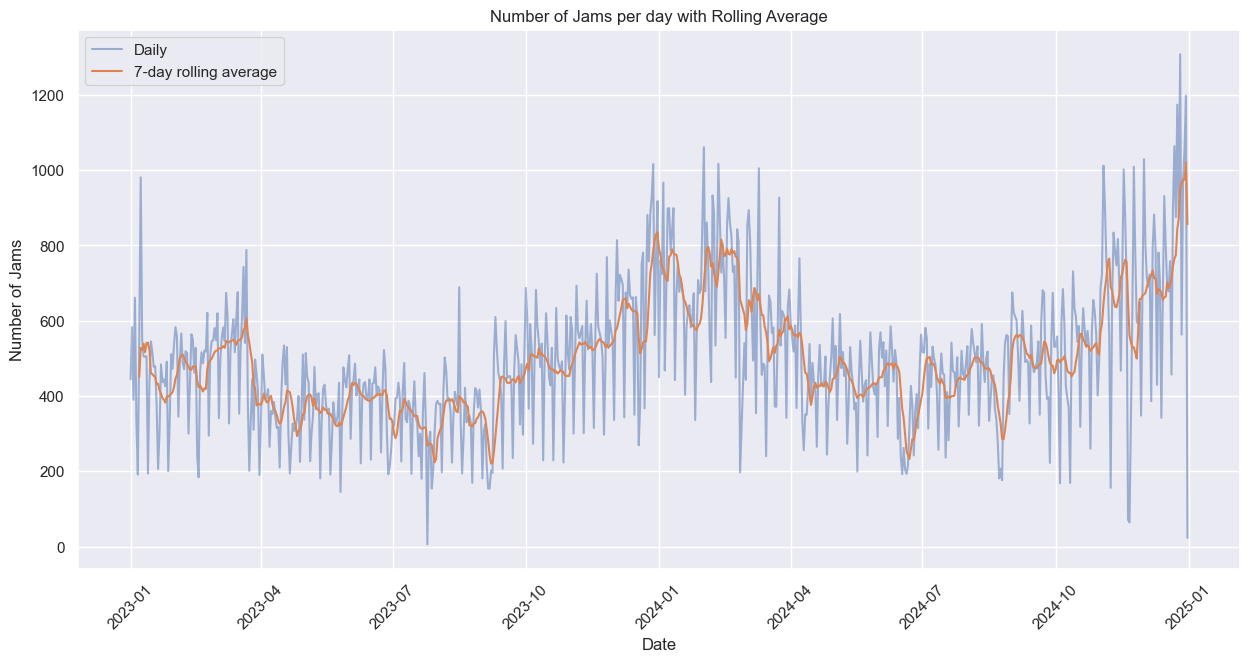

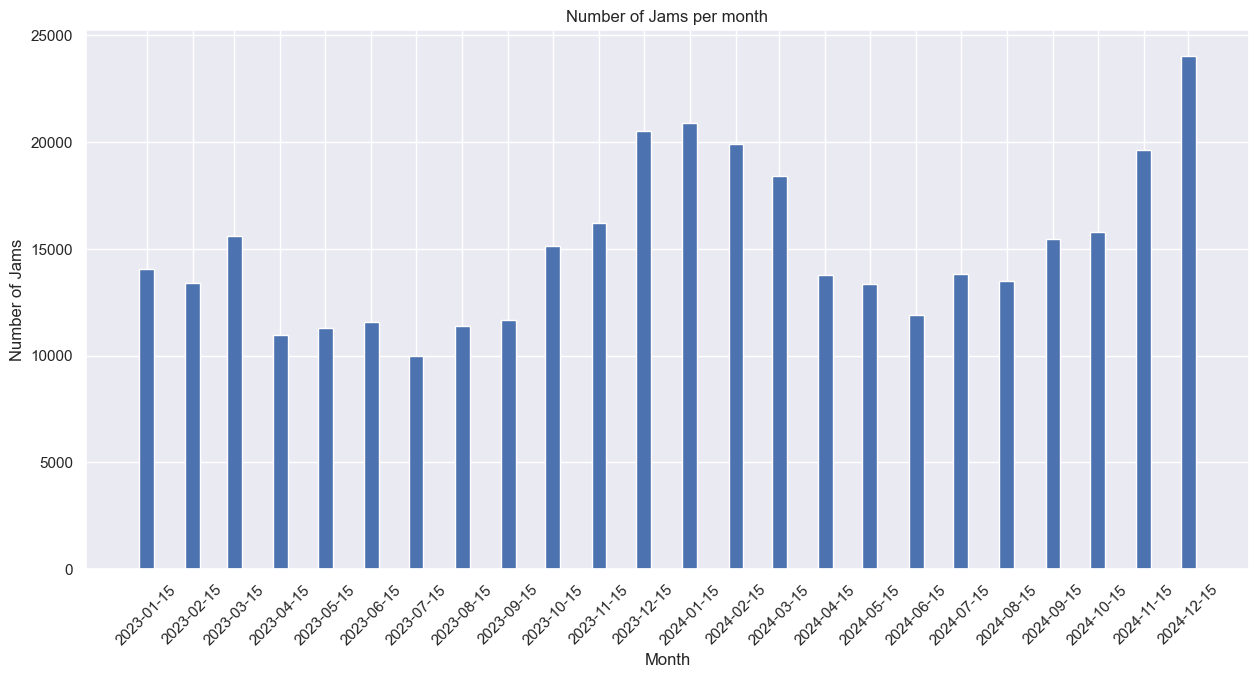

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [7]:
reports.run_basic_report(ddf)

In [8]:
reports.run_geog_report(ddf, geographies, start_date = None, end_date = None)

Running report for Administrative Level 1


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

Running report for Administrative Level 2


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

Running report for Hexagons Level 7


# Basic Analysis

In [9]:
plots.plot_year_to_year_tci(ddf, 'length')

alt.Chart(...)

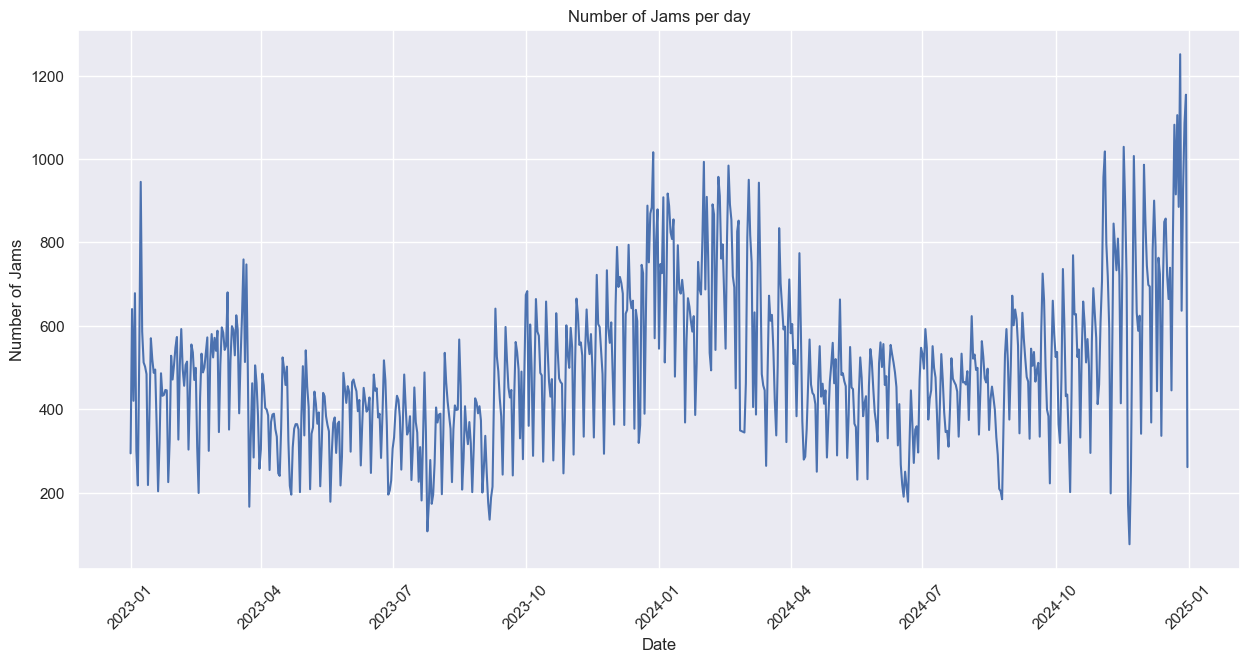

In [9]:
plots.jams_per_day(ddf)

In [10]:
plots.jams_per_day_altair(ddf, save_fig=False)

alt.Chart(...)

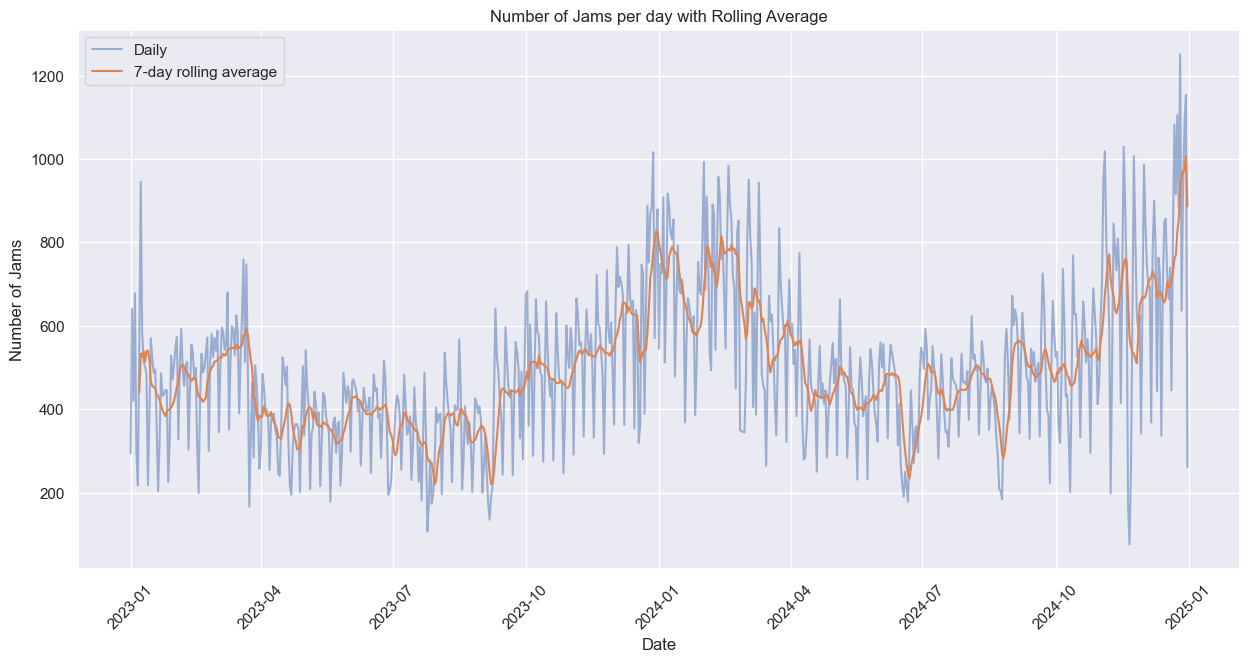

In [11]:
plots.jams_per_day_rolling_avg(ddf, window=7, save_fig=False)

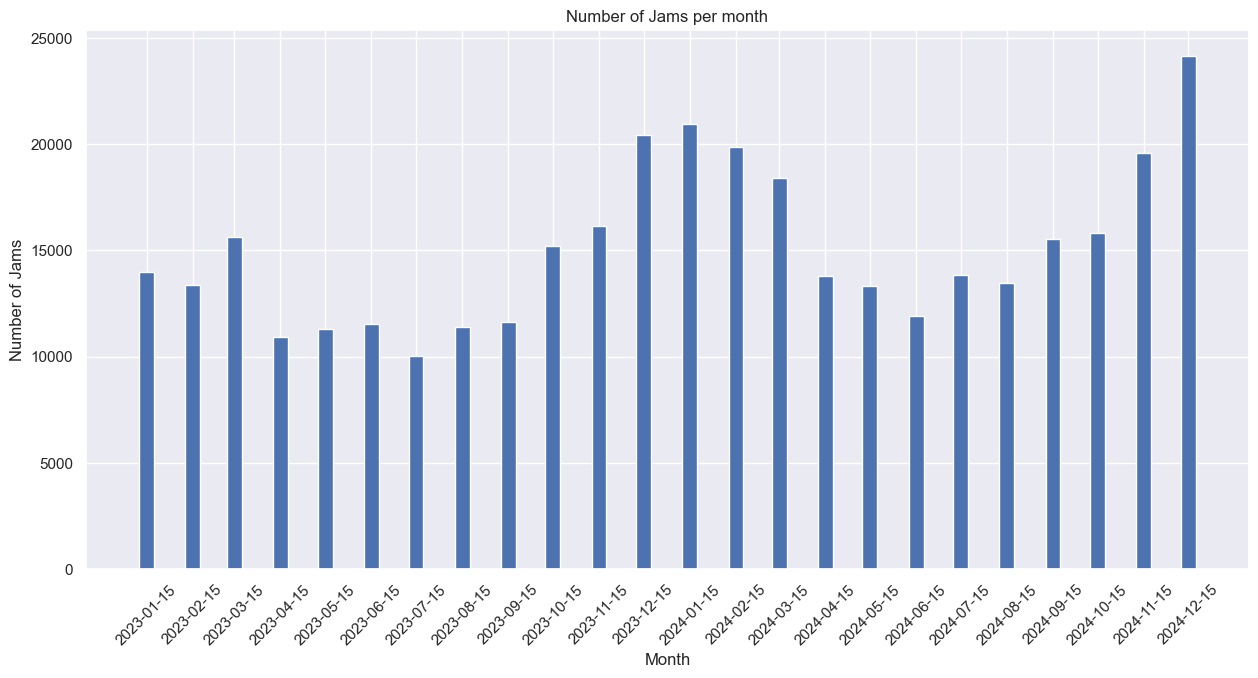

In [12]:
plots.jams_monthly_aggregated(ddf, save_fig = False)

In [8]:
plots.jams_per_day_per_level(ddf, save_fig=False)

alt.Chart(...)

In [10]:
plots.hourly_tci_by_month(ddf, dow = [1,2,3], group_name = 'Mon-Tue-Wed')

alt.Chart(...)

In [8]:
plots.map_tci(ddf, 'admin2', 'length', admin2, start_date = None, end_date = None, dow = None)

In [10]:
plots.map_tci(ddf, 'hex_id_7', 'length', hex_gdf, start_date = None, end_date = None, dow = None)

# Plots for different geography levels

In [9]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['admin1'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [10]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['admin2'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [11]:
plots.plot_tci_by_period_geography(ddf, ['date'], ['region'], 'length', custom_dates = None, save_fig = False)

alt.Chart(...)

In [9]:
start_date = '2023-01-01'
end_date = '2023-12-31'
dow = [1,2,3]
agg_spatial = 'admin2'
agg_column = 'length'
group_name = 'Mon-Tue-Wed'

plots.hourly_tci_by_geog(ddf, agg_spatial, agg_column, group_name, start_date = start_date, end_date = end_date, dow = dow)

alt.Chart(...)

# Accidents